# stock market predictor

## downloading S&P 500 price data

In [25]:
import yfinance as yf
import pandas as pd

In [ ]:
sp500 = yf.Ticker("^GSPC") # get class for s&p500

In [5]:
sp500 = sp500.history(period="max")

In [ ]:
sp500 # show price on single trading day + high/lows
# we will use these columns to predict if stock price will go up or down tomorrow

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,0.0,0.0
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000,0.0,0.0
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,0.0,0.0


In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-02-26 00:00:00-05:00', '2026-02-27 00:00:00-05:00',
               '2026-03-02 00:00:00-05:00', '2026-03-03 00:00:00-05:00',
               '2026-03-04 00:00:00-05:00', '2026-03-05 00:00:00-05:00',
               '2026-03-06 00:00:00-05:00', '2026-03-09 00:00:00-04:00',
               '2026-03-10 00:00:00-04:00', '2026-03-11 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24664, freq=None)

## cleaning and visualizing data

<Axes: xlabel='Date'>

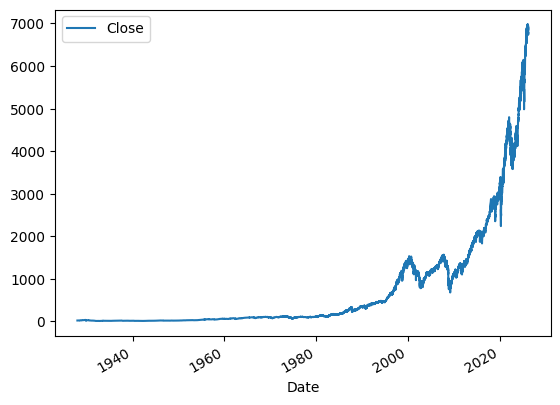

In [9]:
sp500.plot.line(y="Close", use_index=True)

In [10]:
# clean up - remove extra columns
del sp500["Dividends"]
del sp500["Stock Splits"]

In [11]:
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000


In [12]:
# can either predict absolute price or directionality (up or down)
# for stocks, absolute price could not be very helpful, because we want to make money based on if a stock is going up or down
# TARGET: trying to confirm whether a stock will keep going up

sp500["Tomorrow"] = sp500["Close"].shift(-1) # create a "tomorrow" column which has closing price shifted back by 1 day
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000,6795.990234
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980


In [ ]:
# based on tomorrow's price, we can set up a target - whether tomorrow's price is greater than today's
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
sp500 # 0 = price went down, 1 = price went up

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020,0
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000,6795.990234,1
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0


In [15]:
# historical data = good most of the time, but not always for historical data
# remove all data before 1990
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-03-05 00:00:00-05:00,6851.080078,6870.430176,6770.779785,6830.709961,5989300000,6740.020020,0
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000,6795.990234,1
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0


## training an initial ml model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# random forest model = training individual decision trees from many parameters
# averages results from these decision trees -- resistant to overfitting
# runs quickly and can pick up non linear tendencies

In [19]:
# create model
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1) 

n_estimators: number of individual decision trees we want to train - more = higher accurate

min_samples_split: protection against overfitting - decision trees built to deeply have tendency to overfit - higher we set it, the less accurate model will be, but less overfit there will be

random_state: random forest has randomization - setting random state will allow random numbers generated to be in predictable sequence each time - rerunning model twice will get same results

In [20]:
# split model into train and test set
train = sp500.iloc[:-100]
test = sp500.iloc[:-100]

time series data - can't use cross validation

if we did, the results would look amazing in training, horrible in real world. if we use cross validation that doesn't take tiome series nature into account, we would be using future data to predict the past --> LEAKAGE (future data leaks information into model)

predicting stock price tomorrow would be easier if we already knew price in 30 days -- can't have knowledge about future in real world

In [21]:
# list of all of columns we will use to predict target
predictors = ["Close", "Volume", "Open", "High", "Low"]

# fit model - using predictor models to try and predict target
model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


predictor columns should be EXPLICIT - do they actually affect and make predictions accurate in real life?

In [ ]:
# measuer accuracy of model - IMPORTANT
from sklearn.metrics import precision_score

# what percentage of the time when we said market would go up, did it actually go up?
# assume that we want to buy stock - hold, then sell -- need to make sure stock price actually increases
preds = model.predict(test[predictors])
preds # numpy array

array([1, 0, 0, ..., 1, 1, 1], shape=(9014,))

In [28]:
# turn into pandas series
preds = pd.Series(preds, index=test.index)
preds

Date
1990-01-02 00:00:00-05:00    1
1990-01-03 00:00:00-05:00    0
1990-01-04 00:00:00-05:00    0
1990-01-05 00:00:00-05:00    1
1990-01-08 00:00:00-05:00    1
                            ..
2025-10-09 00:00:00-04:00    0
2025-10-10 00:00:00-04:00    1
2025-10-13 00:00:00-04:00    1
2025-10-14 00:00:00-04:00    1
2025-10-15 00:00:00-04:00    1
Length: 9014, dtype: int64

In [30]:
# calculate precision score
precision_score(test["Target"], preds)

0.7170963364993216

the stock price went up 72% of time when we thought it would go up

In [31]:
# we can keep improving the model
combined = pd.concat([test["Target"], preds], axis=1) # combine test and predicted values

<Axes: xlabel='Date'>

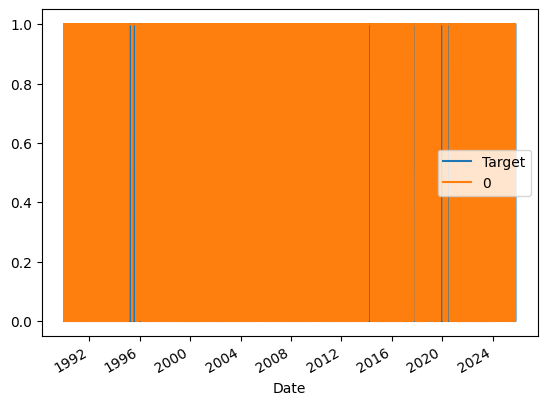

In [32]:
combined.plot()